# Introductory Lab: Python, NumPy, Matplotlib & Qiskit for Quantum Computing

> **Target audience:** Physics students beginning their journey into quantum computing.
> This lab comes *before* the first lecture on quantum computing.

---

## What you will learn

| # | Topic | Tools | Time estimate |
|---|-------|-------|---------------|
| 0 | Google Colab & Python crash course | Python |
| 1 | NumPy: vectors, matrices, eigenvalues | NumPy |
| 2 | Matplotlib & complex numbers | Matplotlib |
| 3 | Dirac (bra-ket) notation | NumPy |
| 4 | The qubit & measurement | NumPy |
| 5 | Quantum gates & the Bloch sphere | NumPy, Qiskit |
| 6 | Multi-qubit systems & entanglement | Qiskit |
| 7 | Your first quantum circuits | Qiskit |


**Assumed background:** complex numbers, basic linear algebra (vectors, matrices, inner products), probability.

**How to use this notebook:**
1. Run every cell **in order** (Shift + Enter).
2. Read the explanations — they build on each other.
3. Pause at **Checkpoint** cells and write your solution in the empty cell *before* looking at the provided answer.
4. Subsections marked **Deep dive (optional)** can be skipped if time is short — come back to them later.
5. If something goes wrong: try *Runtime → Restart runtime*, then re-run all cells from the top.

---

## Getting started with Google Colab

[Google Colab](https://colab.research.google.com) is a **free, browser-based Jupyter notebook environment** hosted by Google. Think of it as a document that mixes formatted text (like this cell) with **executable code cells** (like the next cell).

### Key concepts

| Concept | What it means |
|---------|---------------|
| **Cell** | A block of content — either *Markdown* (text + math) or *Code* (Python). |
| **Runtime** | A virtual machine in the cloud that runs your code. |
| **Kernel** | The Python process inside the runtime. |

### Essential keyboard shortcuts

| Shortcut | Action |
|----------|--------|
| `Shift + Enter` | Run current cell and move to the next one |
| `Ctrl + Enter` | Run current cell and stay |
| `Esc` then `A` | Insert cell **a**bove |
| `Esc` then `B` | Insert cell **b**elow |
| `Esc` then `M` | Convert cell to **M**arkdown |
| `Esc` then `Y` | Convert cell to code |
| `Ctrl + /` | Toggle comment in code cell |

> **Tip:** If something goes wrong, use *Runtime → Restart runtime* to start fresh.

### Try it yourself!

Run the cell below by clicking it and pressing **Shift + Enter**. You should see `Hello, quantum world!` printed underneath.

In [1]:
print("Hello, quantum world!")

Hello, quantum world!


## Setup

The cell below installs the packages we need. On Colab this takes ~30 seconds the first time.
Locally, you can skip it if you already have the packages.

In [2]:
# Install Qiskit (skip if already installed)
!pip -q install qiskit qiskit-aer numpy matplotlib pylatexenc

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
try:
    from qiskit_aer import AerSimulator
    SIM_BACKEND = AerSimulator()
except Exception:
    from qiskit import Aer
    SIM_BACKEND = Aer.get_backend('aer_simulator')

from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram

np.set_printoptions(precision=4, suppress=True)

print("NumPy version:", np.__version__)
try:
    import qiskit
    print("Qiskit version:", qiskit.__version__)
except Exception:
    pass
print("\nAll imports successful — you are ready to go!")

NumPy version: 2.3.5
Qiskit version: 2.3.0

All imports successful — you are ready to go!


---

# Section 0 — Python Crash Course

> **Goal:** Remove friction so you can read and modify the quantum code later.
> We are *not* teaching Python — just the bare minimum you need today.

---

### 0.1 Variables and types

A **variable** is a name that refers to a value. Python figures out the type automatically.

| Type | Example | When you'll see it |
|------|---------|-------------------|
| `int` | `n = 42` | Counting qubits, shots |
| `float` | `p = 0.5` | Probabilities |
| `complex` | `z = 1 + 2j` | Quantum amplitudes |
| `str` | `s = "hello"` | Labels |
| `bool` | `b = True` | Flags |

> **Note:** Python uses `j` (not $i$) for the imaginary unit: `1j` means $i$.

In [4]:
n = 42
p = 0.5
z = 1 + 2j
s = "qubit"
b = True

print("n =", n, "  type:", type(n))
print("p =", p, "  type:", type(p))
print("z =", z, "  type:", type(z))
print("s =", s, "  type:", type(s))
print("b =", b, "  type:", type(b))

n = 42   type: <class 'int'>
p = 0.5   type: <class 'float'>
z = (1+2j)   type: <class 'complex'>
s = qubit   type: <class 'str'>
b = True   type: <class 'bool'>


### 0.2 Lists, tuples, and indexing

A **list** is an ordered, mutable collection. A **tuple** is like a list but immutable.
Both support **indexing** (starting at 0) and **slicing**.

```
      index:  0   1   2   3   4
  my_list = [ 10, 20, 30, 40, 50 ]
             -5  -4  -3  -2  -1     ← negative indices count from the end
```

In [5]:
my_list = [10, 20, 30, 40, 50]

print("First element :", my_list[0])
print("Last element  :", my_list[-1])
print("Slice [1:4]   :", my_list[1:4])
print("Every 2nd     :", my_list[::2])

my_tuple = (3.14, 2.72)
print("\nTuple:", my_tuple, "— cannot be changed after creation")

First element : 10
Last element  : 50
Slice [1:4]   : [20, 30, 40]
Every 2nd     : [10, 30, 50]

Tuple: (3.14, 2.72) — cannot be changed after creation


### 0.3 Loops and conditionals

We'll need `for` loops to iterate over states and `if`/`else` for simple branching.

In [6]:
for i in range(5):
    if i % 2 == 0:
        print(f"{i} is even")
    else:
        print(f"{i} is odd")

0 is even
1 is odd
2 is even
3 is odd
4 is even


### 0.4 Functions

A **function** packages a reusable computation. We will write small helper functions throughout.

For example, the famous mass–energy relation $E = mc^2$:

In [7]:
def energy(m, c=3e8):
    return m * c**2

print(f"E for 1 kg: {energy(1):.2e} J")
print(f"E for 2 kg (c=3): {energy(2, c=3)} (toy units)")

E for 1 kg: 9.00e+16 J
E for 2 kg (c=3): 18 (toy units)


### 0.5 List comprehensions and f-strings

List comprehensions are a compact way to build lists. f-strings (`f"..."`) let you embed expressions.

In [8]:
squares = [x**2 for x in range(6)]
print("Squares:", squares)

evens = [x for x in range(20) if x % 2 == 0]
print("Even numbers < 20:", evens)

name = "qubit"
print(f"Hello, {name}! 2+3 = {2+3}")

Squares: [0, 1, 4, 9, 16, 25]
Even numbers < 20: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Hello, qubit! 2+3 = 5


### Checkpoint 0

**Task:** Write a function `normalize(v)` that takes a list of numbers and returns a new list
where every element is divided by the sum of all elements.

```python
normalize([1, 2, 3, 4])  # should return [0.1, 0.2, 0.3, 0.4]
```

*Hint:* use `sum(v)` and a list comprehension.

In [9]:
def normalize(v):
    s = sum(v)
    return [x / s for x in v]

print(normalize([1, 2, 3, 4]))  # [0.1, 0.2, 0.3, 0.4]

[0.1, 0.2, 0.3, 0.4]


---

# Section 1 — NumPy: Vectors, Matrices, and Eigenvalues

> **Goal:** Learn to represent and manipulate the mathematical objects of quantum mechanics in code.

NumPy is Python's standard library for numerical computing. It provides the `ndarray` —
a fast, multidimensional array type that supports element-wise operations, linear algebra, and more.

---

### 1.1 Creating arrays

In linear algebra we write a column vector as

$$
\mathbf{v} = \begin{bmatrix}1\\2\\3\end{bmatrix}.
$$

In NumPy this is `np.array([1, 2, 3])`. For quantum computing we almost always use `dtype=complex`
because amplitudes are complex numbers.

In [10]:
v = np.array([1, 2, 3], dtype=complex)
w = np.array([3, 0, -1], dtype=complex)

print("v       =", v)
print("shape   =", v.shape)
print("dtype   =", v.dtype)
print("v + w   =", v + w)
print("3 * v   =", 3 * v)

v       = [1.+0.j 2.+0.j 3.+0.j]
shape   = (3,)
dtype   = complex128
v + w   = [4.+0.j 2.+0.j 2.+0.j]
3 * v   = [3.+0.j 6.+0.j 9.+0.j]


### 1.2 Dot product and norm

The **inner product** (dot product) of two vectors $\mathbf{u}, \mathbf{v} \in \mathbb{C}^n$ is

$$
\langle \mathbf{u}, \mathbf{v} \rangle = \sum_{k=1}^{n} u_k^* \, v_k,
$$

and the **norm** is $\|\mathbf{v}\| = \sqrt{\langle \mathbf{v}, \mathbf{v} \rangle}$.

In NumPy:
- **`np.vdot(u, v)`** computes the inner product $\langle \mathbf{u}, \mathbf{v} \rangle$ (conjugating the first argument).
- **`np.linalg.norm(v)`** computes the norm $\|\mathbf{v}\|$.

> In quantum mechanics, the inner product determines *overlap* between states, and the norm must equal 1.

In [11]:
dot_vw = np.vdot(v, w)
norm_v = np.linalg.norm(v)

print("⟨v, w⟩ =", dot_vw)
print("‖v‖    =", norm_v)

v_normalized = v / norm_v
print("v̂      =", v_normalized)
print("‖v̂‖    =", np.linalg.norm(v_normalized))

⟨v, w⟩ = 0j
‖v‖    = 3.7416573867739413
v̂      = [0.2673+0.j 0.5345+0.j 0.8018+0.j]
‖v̂‖    = 1.0


### 1.3 Matrices and matrix multiplication

A **matrix** is a 2D array. Matrix–vector multiplication $A\mathbf{v}$ is written with the `@` operator.

$$
A = \begin{bmatrix}1 & 2\\3 & 4\end{bmatrix}, \quad
A \begin{bmatrix}1\\1\end{bmatrix} = \begin{bmatrix}3\\7\end{bmatrix}.
$$

In [12]:
A = np.array([[1, 2],
              [3, 4]], dtype=complex)

x = np.array([1, 1], dtype=complex)

print("A =\n", A)
print("A @ x =", A @ x)
print("A.T (transpose) =\n", A.T)
print("A† (conjugate transpose) =\n", A.conj().T)

A =
 [[1.+0.j 2.+0.j]
 [3.+0.j 4.+0.j]]
A @ x = [3.+0.j 7.+0.j]
A.T (transpose) =
 [[1.+0.j 3.+0.j]
 [2.+0.j 4.+0.j]]
A† (conjugate transpose) =
 [[1.-0.j 3.-0.j]
 [2.-0.j 4.-0.j]]


### 1.4 Special matrices and useful NumPy helpers

Several matrix types appear constantly in quantum computing:

| Name | Symbol | Property |
|------|--------|----------|
| Identity | $I$ | $I\mathbf{v} = \mathbf{v}$ for all $\mathbf{v}$ |
| Hermitian | $H = H^\dagger$ | Real eigenvalues (observables) |
| Unitary | $U^\dagger U = I$ | Preserves norms (quantum gates) |

Before we verify these properties in code, let's meet three NumPy tools we'll use constantly:

| Function | What it does | Example |
|----------|-------------|---------|
| `np.eye(n)` | Creates the $n \times n$ identity matrix $I$ | `np.eye(2)` → $\begin{bmatrix}1&0\\0&1\end{bmatrix}$ |
| `A.conj().T` | Conjugate transpose $A^\dagger$ (flip + complex conjugate) | needed to check $H = H^\dagger$ |
| `np.allclose(A, B)` | Returns `True` if every element of $A$ and $B$ is approximately equal (up to floating-point tolerance) | `np.allclose(H, H.conj().T)` checks Hermiticity |

> **Why `np.allclose` instead of `==`?** Floating-point arithmetic introduces tiny rounding errors
> (e.g., `1/3 * 3` might give `0.9999999999999999` instead of `1.0`).
> `np.allclose` accounts for this by checking if values match within a small tolerance ($\sim 10^{-8}$).

In [13]:
I2 = np.eye(2, dtype=complex)
print("Identity:\n", I2)

H_mat = np.array([[2, 1+1j],
                   [1-1j, 3]], dtype=complex)
print("\nHermitian? (H = H†):", np.allclose(H_mat, H_mat.conj().T))

U = (1/np.sqrt(2)) * np.array([[1, 1],
                                 [1, -1]], dtype=complex)
print("Unitary?  (U†U = I):", np.allclose(U.conj().T @ U, I2))

Identity:
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Hermitian? (H = H†): True
Unitary?  (U†U = I): True


### 1.5 Eigenvalues and eigenvectors

An **eigenvector** $\mathbf{v}$ of a matrix $A$ satisfies

$$
A\mathbf{v} = \lambda \mathbf{v}
$$

for some scalar $\lambda$ (the **eigenvalue**). In quantum mechanics:
- **Observables** are Hermitian matrices — their eigenvalues are the possible measurement outcomes.
- **States** are eigenvectors — measuring an observable on its eigenvector gives a definite result.

In NumPy, **`np.linalg.eigh(A)`** computes the eigenvalues and eigenvectors of a Hermitian matrix.
It returns a tuple `(eigenvalues, eigenvectors)` where the eigenvectors are stored as *columns* of a matrix.

In [14]:
eigenvalues, eigenvectors = np.linalg.eigh(H_mat)

print("Eigenvalues:", eigenvalues)
print("\nEigenvectors (columns):\n", eigenvectors)

for i in range(len(eigenvalues)):
    v_i = eigenvectors[:, i]
    print(f"\nCheck A·v{i} = λ{i}·v{i}:",
          np.allclose(H_mat @ v_i, eigenvalues[i] * v_i))

Eigenvalues: [1. 4.]

Eigenvectors (columns):
 [[-0.8165+0.j     -0.5774+0.j    ]
 [ 0.4082-0.4082j -0.5774+0.5774j]]

Check A·v0 = λ0·v0: True

Check A·v1 = λ1·v1: True


### Checkpoint 1

**Task:** Create the matrix
$$
\sigma_z = \begin{bmatrix}1 & 0\\0 & -1\end{bmatrix}
$$
and find its eigenvalues and eigenvectors. Verify that the eigenvectors are orthogonal ($\langle v_0, v_1 \rangle = 0$).

*This matrix is the Pauli-Z operator — you'll meet it again in Section 5.*

In [15]:
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

eigenvalues, eigenvectors = np.linalg.eigh(sigma_z)

print("σ_z =\n", sigma_z)
print("\nEigenvalues:", eigenvalues)
print("\nEigenvectors (columns):\n", eigenvectors)

v0 = eigenvectors[:, 0]
v1 = eigenvectors[:, 1]
print(f"\n⟨v0, v1⟩ = {np.vdot(v0, v1)}")
print("Orthogonal?", np.allclose(np.vdot(v0, v1), 0))

σ_z =
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Eigenvalues: [-1.  1.]

Eigenvectors (columns):
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

⟨v0, v1⟩ = 0j
Orthogonal? True


---

# Section 2 — Matplotlib & Complex Numbers

> **Goal:** Visualize functions, probability distributions, and complex amplitudes.

---

### 2.1 Line plots

Matplotlib's `plt.plot(x, y)` draws a line through the points $(x_i, y_i)$.
We will later use this to plot probability distributions and wave functions.

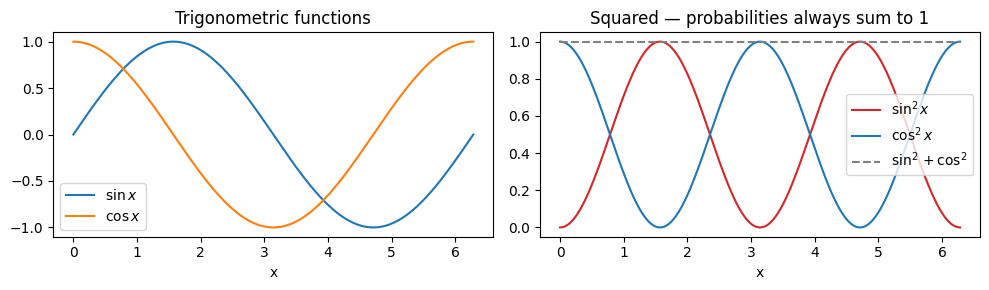

In [16]:
x = np.linspace(0, 2*np.pi, 300)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(x, np.sin(x), label=r'$\sin x$')
axes[0].plot(x, np.cos(x), label=r'$\cos x$')
axes[0].set_xlabel('x')
axes[0].legend()
axes[0].set_title('Trigonometric functions')

axes[1].plot(x, np.sin(x)**2, label=r'$\sin^2 x$', color='tab:red')
axes[1].plot(x, np.cos(x)**2, label=r'$\cos^2 x$', color='tab:blue')
axes[1].plot(x, np.sin(x)**2 + np.cos(x)**2, '--', label=r'$\sin^2+\cos^2$', color='gray')
axes[1].set_xlabel('x')
axes[1].legend()
axes[1].set_title(r'Squared — probabilities always sum to 1')

plt.tight_layout()
plt.show()

### 2.2 Bar charts for discrete data

Quantum measurement outcomes are discrete — we'll use bar charts to visualize counts and probabilities.

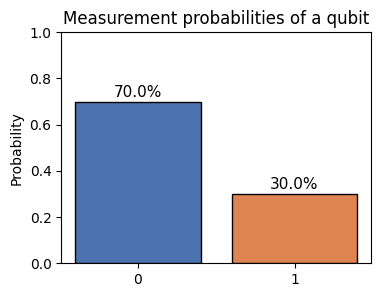

In [17]:
outcomes = ['0', '1']
probs = [0.7, 0.3]

plt.figure(figsize=(4, 3))
bars = plt.bar(outcomes, probs, color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('Probability')
plt.title('Measurement probabilities of a qubit')
for bar, p in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{p:.1%}', ha='center', fontsize=11)
plt.show()

### 2.3 Complex numbers and Euler's formula

Quantum amplitudes are **complex numbers** $z = a + bi$ where $a, b \in \mathbb{R}$ and $i = \sqrt{-1}$.

Every complex number has a **polar form**:

$$
z = r \, e^{i\theta} = r(\cos\theta + i\sin\theta),
$$

where $r = |z|$ is the **magnitude** and $\theta = \arg(z)$ is the **phase**.

**Euler's formula** — one of the most beautiful results in mathematics — is the special case $r = 1$:

$$
\boxed{e^{i\theta} = \cos\theta + i\sin\theta.}
$$

The set of all $e^{i\theta}$ traces out the **unit circle** in the complex plane.

In [18]:
theta = np.pi / 3
z = np.exp(1j * theta)

print(f"θ = π/3 ≈ {theta:.4f}")
print(f"z = e^(iθ) = {z:.4f}")
print(f"|z| = {abs(z):.4f}")
print(f"arg(z) = {np.angle(z):.4f} rad = {np.degrees(np.angle(z)):.1f}°")
print(f"conjugate z* = {np.conj(z):.4f}")
print(f"z · z* = |z|² = {(z * np.conj(z)).real:.4f}")

θ = π/3 ≈ 1.0472
z = e^(iθ) = 0.5000+0.8660j
|z| = 1.0000
arg(z) = 1.0472 rad = 60.0°
conjugate z* = 0.5000-0.8660j
z · z* = |z|² = 1.0000


### 2.4 Visualizing the complex plane

> **Deep dive (optional)** — skip this subsection if short on time.

Let's plot several complex numbers and the unit circle. This picture makes magnitude and phase geometric.

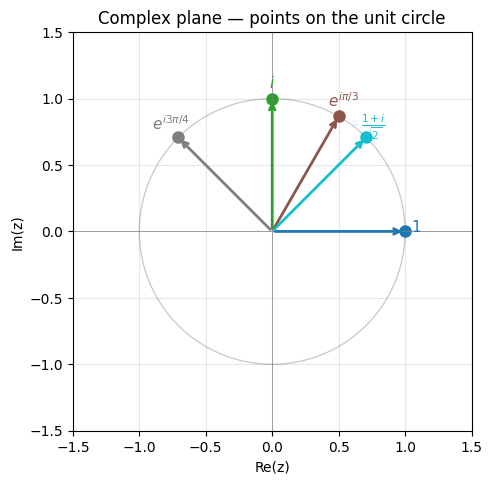

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))

circle = np.exp(1j * np.linspace(0, 2*np.pi, 200))
ax.plot(circle.real, circle.imag, 'k-', alpha=0.2, linewidth=1)

points = {
    r'$1$': 1+0j,
    r'$i$': 0+1j,
    r'$e^{i\pi/3}$': np.exp(1j*np.pi/3),
    r'$e^{i3\pi/4}$': np.exp(1j*3*np.pi/4),
    r'$\frac{1+i}{\sqrt{2}}$': (1+1j)/np.sqrt(2),
}

colors = plt.cm.tab10(np.linspace(0, 1, len(points)))
for (label, z), color in zip(points.items(), colors):
    ax.annotate('', xy=(z.real, z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.plot(z.real, z.imag, 'o', color=color, markersize=8)
    offset = 0.08 * np.exp(1j * np.angle(z))
    ax.text(z.real + offset.real, z.imag + offset.imag, label,
            fontsize=11, ha='center', color=color)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title('Complex plane — points on the unit circle')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 Why phases matter: interference

> **Deep dive (optional)** — skip this subsection if short on time.

Two complex numbers can **add constructively** (same phase → bigger magnitude) or
**destructively** (opposite phase → smaller magnitude). This is the origin of quantum interference.

$$
\underbrace{e^{i0} + e^{i0}}_{= 2} \quad\text{vs.}\quad \underbrace{e^{i0} + e^{i\pi}}_{= 0}.
$$

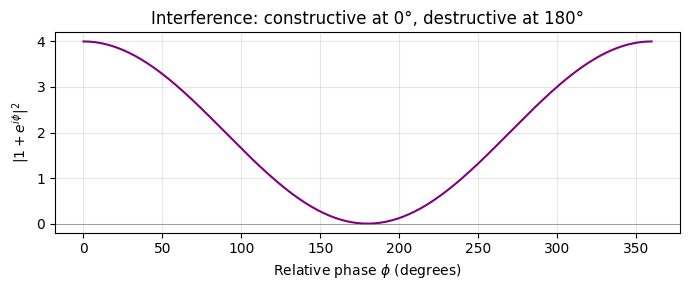

In [20]:
phases = np.linspace(0, 2*np.pi, 200)
z1 = np.ones_like(phases)
z2 = np.exp(1j * phases)
total = z1 + z2

plt.figure(figsize=(7, 3))
plt.plot(np.degrees(phases), np.abs(total)**2, color='purple')
plt.xlabel(r'Relative phase $\phi$ (degrees)')
plt.ylabel(r'$|1 + e^{i\phi}|^2$')
plt.title('Interference: constructive at 0°, destructive at 180°')
plt.axhline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Section 3 — Dirac (Bra-Ket) Notation

> **Goal:** Master the notation that physicists use for quantum states.

Dirac notation is the *lingua franca* of quantum mechanics. It provides an elegant, basis-independent
way to write states, inner products, and operators.

---

### The dictionary

| Dirac notation | Linear algebra | NumPy |
|----------------|---------------|-------|
| $\lvert\psi\rangle$ (ket) | column vector $\mathbf{v}$ | `np.array([[a],[b]])` |
| $\langle\psi\rvert$ (bra) | conjugate-transpose row vector $\mathbf{v}^\dagger$ | `v.conj().T` |
| $\langle\phi\lvert\psi\rangle$ (braket) | inner product $\mathbf{u}^\dagger \mathbf{v}$ | `np.vdot(u, v)` |
| $\lvert\psi\rangle\langle\phi\rvert$ (outer product) | matrix $\mathbf{v}\mathbf{u}^\dagger$ | `v @ u.conj().T` |

### 3.1 Kets: $|\psi\rangle$ as column vectors

A **ket** $|\psi\rangle$ represents a quantum state. For a qubit, the two **computational basis** states are

$$
|0\rangle = \begin{bmatrix}1\\0\end{bmatrix}, \qquad
|1\rangle = \begin{bmatrix}0\\1\end{bmatrix}.
$$

Any qubit state is a **superposition**:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{bmatrix}\alpha\\\beta\end{bmatrix},
\quad \alpha,\beta\in\mathbb{C}, \quad |\alpha|^2 + |\beta|^2 = 1.
$$

The numbers $\alpha$ and $\beta$ are called **probability amplitudes**.

In [21]:
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

print("|0⟩ =\n", ket0)
print("|1⟩ =\n", ket1)

alpha = 1 / np.sqrt(3)
beta  = np.sqrt(2/3) * np.exp(1j * np.pi/4)
psi   = alpha * ket0 + beta * ket1

print(f"\nα = {alpha:.4f}")
print(f"β = {beta:.4f}")
print("|ψ⟩ =\n", psi)
print(f"‖|ψ⟩‖² = {np.vdot(psi, psi).real:.4f}")

|0⟩ =
 [[1.+0.j]
 [0.+0.j]]
|1⟩ =
 [[0.+0.j]
 [1.+0.j]]

α = 0.5774
β = 0.5774+0.5774j
|ψ⟩ =
 [[0.5774+0.j    ]
 [0.5774+0.5774j]]
‖|ψ⟩‖² = 1.0000


### 3.2 Bras: $\langle\psi|$ as conjugate-transpose row vectors

The **bra** $\langle\psi|$ is obtained by taking the *conjugate transpose* of the ket:

$$
\text{If } |\psi\rangle = \begin{bmatrix}\alpha\\\beta\end{bmatrix},
\quad\text{then } \langle\psi| = \begin{bmatrix}\alpha^* & \beta^*\end{bmatrix}.
$$

The conjugate transpose is also called the **Hermitian conjugate** or **dagger** ($\dagger$).

In [22]:
bra_psi = psi.conj().T

print("|ψ⟩ =\n", psi)
print("⟨ψ| =", bra_psi)

|ψ⟩ =
 [[0.5774+0.j    ]
 [0.5774+0.5774j]]
⟨ψ| = [[0.5774-0.j     0.5774-0.5774j]]


### 3.3 The inner product $\langle\phi|\psi\rangle$

The **inner product** (or *braket*) of two states gives a complex number that measures their *overlap*:

$$
\langle\phi|\psi\rangle = \phi_0^*\psi_0 + \phi_1^*\psi_1.
$$

Key properties:
- $\langle\psi|\psi\rangle = 1$ for normalized states (**normalization condition**).
- $\langle\phi|\psi\rangle = 0$ means the states are **orthogonal** (perfectly distinguishable).
- $|\langle\phi|\psi\rangle|^2$ is the **probability** of finding $|\psi\rangle$ in state $|\phi\rangle$.

In [23]:
inner = np.vdot(ket0, ket1)
print("⟨0|1⟩ =", inner, " (orthogonal)")

inner_self = np.vdot(ket0, ket0)
print("⟨0|0⟩ =", inner_self, " (normalized)")

plus = (ket0 + ket1) / np.sqrt(2)
inner_0_plus = np.vdot(ket0, plus)
print(f"⟨0|+⟩ = {inner_0_plus:.4f}")
print(f"|⟨0|+⟩|² = {abs(inner_0_plus)**2:.4f}  (probability of measuring |0⟩ in state |+⟩)")

⟨0|1⟩ = 0j  (orthogonal)
⟨0|0⟩ = (1+0j)  (normalized)
⟨0|+⟩ = 0.7071+0.0000j
|⟨0|+⟩|² = 0.5000  (probability of measuring |0⟩ in state |+⟩)


### 3.4 The outer product $|\psi\rangle\langle\phi|$

The **outer product** is a *matrix* formed from two state vectors:

$$
|\psi\rangle\langle\phi| = \begin{bmatrix}\alpha\\\beta\end{bmatrix}\begin{bmatrix}\gamma^* & \delta^*\end{bmatrix}
= \begin{bmatrix}\alpha\gamma^* & \alpha\delta^*\\\beta\gamma^* & \beta\delta^*\end{bmatrix}.
$$

Important special cases:
- $|0\rangle\langle 0|$ and $|1\rangle\langle 1|$ are **projection operators**.
- The **completeness relation**: $|0\rangle\langle 0| + |1\rangle\langle 1| = I$.
- Any operator can be written as a sum of outer products (**spectral decomposition**).

In [24]:
P0 = ket0 @ ket0.conj().T
P1 = ket1 @ ket1.conj().T

print("|0⟩⟨0| =\n", P0)
print("|1⟩⟨1| =\n", P1)
print("Completeness: |0⟩⟨0| + |1⟩⟨1| =\n", P0 + P1)

print(f"\nProjecting |ψ⟩ onto |0⟩: P₀|ψ⟩ =\n{P0 @ psi}")
print(f"Probability = ⟨ψ|P₀|ψ⟩ = {(psi.conj().T @ P0 @ psi)[0,0].real:.4f}")

|0⟩⟨0| =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
|1⟩⟨1| =
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Completeness: |0⟩⟨0| + |1⟩⟨1| =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Projecting |ψ⟩ onto |0⟩: P₀|ψ⟩ =
[[0.5774+0.j]
 [0.    +0.j]]
Probability = ⟨ψ|P₀|ψ⟩ = 0.3333


### 3.5 Summary of Dirac notation

$$
\boxed{
\begin{aligned}
&\text{Ket: } |\psi\rangle \in \mathbb{C}^2 \quad \text{(column vector — the state)}\\[4pt]
&\text{Bra: } \langle\psi| = (|\psi\rangle)^\dagger \quad \text{(row vector — the dual)}\\[4pt]
&\text{Inner product: } \langle\phi|\psi\rangle \in \mathbb{C} \quad \text{(overlap / transition amplitude)}\\[4pt]
&\text{Outer product: } |\psi\rangle\langle\phi| \quad \text{(operator / matrix)}\\[4pt]
&\text{Normalization: } \langle\psi|\psi\rangle = 1\\[4pt]
&\text{Orthogonality: } \langle 0|1\rangle = 0\\[4pt]
&\text{Born rule: } \Pr(\text{outcome } k) = |\langle k|\psi\rangle|^2
\end{aligned}
}
$$

### Checkpoint 2

**Task:** Compute the following by hand *and* verify with NumPy:

1. $\langle +|-\rangle$ where $|+\rangle = \frac{|0\rangle+|1\rangle}{\sqrt{2}}$ and $|-\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}}$.
2. The outer product $|+\rangle\langle +|$.
3. The probability $|\langle 1|+\rangle|^2$.

*Expected:* (1) $0$ — they are orthogonal; (2) the Hadamard projector; (3) $1/2$.

In [25]:
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

plus  = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)

# 1. ⟨+|−⟩
inner_pm = np.vdot(plus, minus)
print(f"⟨+|−⟩ = {inner_pm:.4f}  (orthogonal)")

# 2. |+⟩⟨+| (outer product)
proj_plus = plus @ plus.conj().T
print(f"\n|+⟩⟨+| =\n{proj_plus}")

# 3. |⟨1|+⟩|²
inner_1_plus = np.vdot(ket1, plus)
prob = abs(inner_1_plus)**2
print(f"\n|⟨1|+⟩|² = {prob:.4f}")

⟨+|−⟩ = 0.0000+0.0000j  (orthogonal)

|+⟩⟨+| =
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

|⟨1|+⟩|² = 0.5000


---

# Section 4 — The Qubit and Measurement

> **Goal:** Understand what a qubit *is*, how measurement works, and the role of phase.

---

### 4.1 The qubit: a two-level quantum system

A **qubit** (quantum bit) is the fundamental unit of quantum information.
Unlike a classical bit (0 or 1), a qubit can exist in a **superposition**:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \quad |\alpha|^2 + |\beta|^2 = 1.
$$

The normalization condition ensures that probabilities sum to 1.

Physical realizations of qubits include:
- **Superconducting circuits** (IBM, Google)
- **Trapped ions** (IonQ, Quantinuum)
- **Photon polarization** (horizontal $\leftrightarrow |0\rangle$, vertical $\leftrightarrow |1\rangle$)
- **Electron spin** (spin-up $\leftrightarrow |0\rangle$, spin-down $\leftrightarrow |1\rangle$)

### 4.2 The Born rule: from amplitudes to probabilities

The **Born rule** is the bridge between the mathematical formalism and experimental results.

> When we measure a qubit in the computational basis, the probability of outcome $|k\rangle$ is
> $$\Pr(k) = |\langle k|\psi\rangle|^2 = |\text{amplitude of } |k\rangle|^2.$$

For a general state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$:
- $\Pr(0) = |\alpha|^2$
- $\Pr(1) = |\beta|^2$

**Measurement is irreversible** — after measurement, the state *collapses* to the observed outcome.

|ψ⟩ = 0.5774|0⟩ + 0.8165|1⟩
Pr(0) = |α|² = 0.3333
Pr(1) = |β|² = 0.6667
Sum   = 1.0000


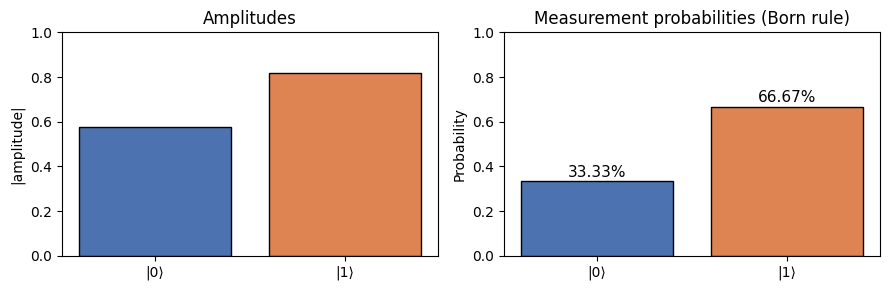

In [26]:
alpha = 1 / np.sqrt(3)
beta  = np.sqrt(2/3)
psi_state = alpha * ket0 + beta * ket1

p0 = abs(alpha)**2
p1 = abs(beta)**2

print(f"|ψ⟩ = {alpha:.4f}|0⟩ + {beta:.4f}|1⟩")
print(f"Pr(0) = |α|² = {p0:.4f}")
print(f"Pr(1) = |β|² = {p1:.4f}")
print(f"Sum   = {p0 + p1:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

bars = axes[0].bar(['|0⟩', '|1⟩'], [abs(alpha), abs(beta)],
                    color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_ylabel('|amplitude|')
axes[0].set_title('Amplitudes')
axes[0].set_ylim(0, 1)

bars = axes[1].bar(['|0⟩', '|1⟩'], [p0, p1],
                    color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[1].set_ylabel('Probability')
axes[1].set_title('Measurement probabilities (Born rule)')
axes[1].set_ylim(0, 1)
for bar, p in zip(bars, [p0, p1]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{p:.2%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 4.3 Global phase vs. relative phase

Not all complex phases are created equal!

**Global phase** $e^{i\gamma}$: multiplies the *entire* state.
$$|\psi'\rangle = e^{i\gamma}|\psi\rangle \quad\Rightarrow\quad \text{same probabilities, same physics.}$$

States that differ only by a global phase are **physically identical**.

**Relative phase** $e^{i\phi}$: multiplies *one amplitude* relative to another.
$$|\psi\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\phi}|1\rangle\bigr)$$

This *does* change measurable properties — it moves the state on the Bloch sphere (see Section 5).

> **Key insight:** Global phase is unobservable; relative phase creates interference and is *very* observable.

In [27]:
psi_base = (ket0 + ket1) / np.sqrt(2)

print("=== Global phase (unobservable) ===")
for gamma in [0, np.pi/4, np.pi/2, np.pi]:
    psi_g = np.exp(1j * gamma) * psi_base
    p0g = abs(psi_g[0,0])**2
    p1g = abs(psi_g[1,0])**2
    print(f"  γ = {gamma:.2f}:  Pr(0) = {p0g:.4f},  Pr(1) = {p1g:.4f}")

print("\n=== Relative phase (observable!) ===")
for phi in [0, np.pi/4, np.pi/2, np.pi]:
    psi_r = (ket0 + np.exp(1j * phi) * ket1) / np.sqrt(2)
    p0r = abs(psi_r[0,0])**2
    p1r = abs(psi_r[1,0])**2
    print(f"  φ = {phi:.2f}:  Pr(0) = {p0r:.4f},  Pr(1) = {p1r:.4f}  (same in Z-basis!)")

print("\n→ Relative phase doesn't change Z-basis probabilities,")
print("  but it DOES change X-basis probabilities (after applying H before measurement).")

=== Global phase (unobservable) ===
  γ = 0.00:  Pr(0) = 0.5000,  Pr(1) = 0.5000
  γ = 0.79:  Pr(0) = 0.5000,  Pr(1) = 0.5000
  γ = 1.57:  Pr(0) = 0.5000,  Pr(1) = 0.5000
  γ = 3.14:  Pr(0) = 0.5000,  Pr(1) = 0.5000

=== Relative phase (observable!) ===
  φ = 0.00:  Pr(0) = 0.5000,  Pr(1) = 0.5000  (same in Z-basis!)
  φ = 0.79:  Pr(0) = 0.5000,  Pr(1) = 0.5000  (same in Z-basis!)
  φ = 1.57:  Pr(0) = 0.5000,  Pr(1) = 0.5000  (same in Z-basis!)
  φ = 3.14:  Pr(0) = 0.5000,  Pr(1) = 0.5000  (same in Z-basis!)

→ Relative phase doesn't change Z-basis probabilities,
  but it DOES change X-basis probabilities (after applying H before measurement).


### 4.4 Visualizing relative phase: measurement in the X-basis

> **Deep dive (optional)** — skip this subsection if short on time.

To *see* the relative phase, we measure in a different basis.
Applying a Hadamard $H$ before measurement effectively measures in the **X-basis** ($|+\rangle$, $|-\rangle$).

$$
H|\psi\rangle = H\cdot\frac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\phi}|1\rangle\bigr)
= \frac{1+e^{i\phi}}{2}|0\rangle + \frac{1-e^{i\phi}}{2}|1\rangle.
$$

Now the probabilities *do* depend on $\phi$!

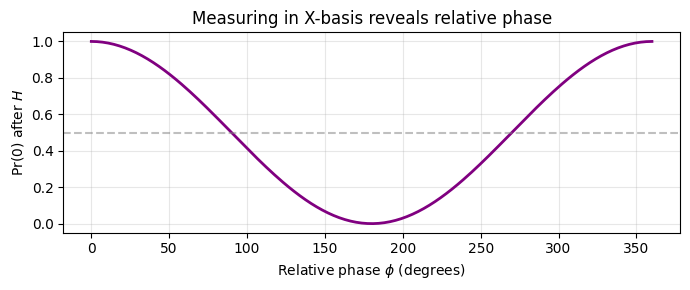

In [28]:
H_gate = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

phis = np.linspace(0, 2*np.pi, 200)
p0_xbasis = []

for phi in phis:
    psi_phi = (ket0 + np.exp(1j * phi) * ket1) / np.sqrt(2)
    psi_after_H = H_gate @ psi_phi
    p0_xbasis.append(abs(psi_after_H[0,0])**2)

plt.figure(figsize=(7, 3))
plt.plot(np.degrees(phis), p0_xbasis, color='purple', linewidth=2)
plt.xlabel(r'Relative phase $\phi$ (degrees)')
plt.ylabel(r'$\Pr(0)$ after $H$')
plt.title(r'Measuring in X-basis reveals relative phase')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Checkpoint 3

**Task:**
1. Create the state $|\psi\rangle$ with $\Pr(0) = 0.25$ and $\Pr(1) = 0.75$.
2. Multiply by a global phase $e^{i\pi/2}$ and verify probabilities don't change.
3. Create $|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + i|1\rangle)$ and compute the X-basis probabilities.

*Hint:* For (1), $\alpha = \sqrt{0.25} = 0.5$, $\beta = \sqrt{0.75}$.

In [29]:
# Checkpoint 3
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)
H_gate = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

# 1. State with Pr(0) = 0.25, Pr(1) = 0.75
alpha = np.sqrt(0.25)
beta = np.sqrt(0.75)
psi = alpha * ket0 + beta * ket1
print(f"|ψ⟩ = {alpha:.4f}|0⟩ + {beta:.4f}|1⟩")
print(f"Pr(0) = {abs(psi[0,0])**2:.4f}")
print(f"Pr(1) = {abs(psi[1,0])**2:.4f}")

# 2. Multiply by global phase e^(iπ/2) and verify
psi_global = np.exp(1j * np.pi/2) * psi
print(f"\nAfter global phase e^(iπ/2):")
print(f"Pr(0) = {abs(psi_global[0,0])**2:.4f}")
print(f"Pr(1) = {abs(psi_global[1,0])**2:.4f}")
print("Probabilities unchanged:", np.allclose(abs(psi)**2, abs(psi_global)**2))

# 3. |ψ⟩ = (|0⟩ + i|1⟩)/√2, X-basis probabilities
psi_i = (ket0 + 1j * ket1) / np.sqrt(2)
psi_after_H = H_gate @ psi_i
print(f"\n|ψ⟩ = (|0⟩ + i|1⟩)/√2")
print(f"X-basis: Pr(+) = {abs(psi_after_H[0,0])**2:.4f}")
print(f"X-basis: Pr(−) = {abs(psi_after_H[1,0])**2:.4f}")

|ψ⟩ = 0.5000|0⟩ + 0.8660|1⟩
Pr(0) = 0.2500
Pr(1) = 0.7500

After global phase e^(iπ/2):
Pr(0) = 0.2500
Pr(1) = 0.7500
Probabilities unchanged: True

|ψ⟩ = (|0⟩ + i|1⟩)/√2
X-basis: Pr(+) = 0.5000
X-basis: Pr(−) = 0.5000


---

# Section 5 — Quantum Gates and the Bloch Sphere

> **Goal:** Understand gates as unitary matrices and visualize them as rotations.

---

### 5.1 What is a quantum gate?

A **quantum gate** is a reversible transformation of a qubit state.
Mathematically, it is a **unitary matrix** $U$ satisfying

$$
U^\dagger U = U U^\dagger = I.
$$

Unitarity ensures:
- **Norm preservation:** $\langle\psi|\psi\rangle = 1 \;\Rightarrow\; \langle\psi|U^\dagger U|\psi\rangle = 1$. Probabilities still sum to 1.
- **Reversibility:** $U^{-1} = U^\dagger$ always exists.

For a single qubit, every gate is a $2\times 2$ unitary matrix.

### 5.2 The Pauli gates: $X$, $Y$, $Z$

The three **Pauli matrices** are the most fundamental single-qubit gates:

$$
X = \begin{bmatrix}0 & 1\\1 & 0\end{bmatrix}, \quad
Y = \begin{bmatrix}0 & -i\\i & 0\end{bmatrix}, \quad
Z = \begin{bmatrix}1 & 0\\0 & -1\end{bmatrix}.
$$

| Gate | Classical analogy | Action on basis states |
|------|------------------|----------------------|
| $X$ | NOT gate | $X\lvert 0\rangle = \lvert 1\rangle$, $X\lvert 1\rangle = \lvert 0\rangle$ |
| $Y$ | bit-flip + phase | $Y\lvert 0\rangle = i\lvert 1\rangle$, $Y\lvert 1\rangle = -i\lvert 0\rangle$ |
| $Z$ | phase-flip | $Z\lvert 0\rangle = \lvert 0\rangle$, $Z\lvert 1\rangle = -\lvert 1\rangle$ |

All three are both **Hermitian** ($P = P^\dagger$) and **unitary** ($P^\dagger P = I$).
They also satisfy $P^2 = I$ — applying any Pauli gate twice returns to the original state.

In [30]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)

print("=== Pauli gate properties ===")
for name, gate in [('X', X), ('Y', Y), ('Z', Z)]:
    print(f"\n{name} =\n{gate}")
    print(f"  Hermitian? (P = P†): {np.allclose(gate, gate.conj().T)}")
    print(f"  Unitary?  (P†P = I): {np.allclose(gate.conj().T @ gate, I2)}")
    print(f"  P² = I?            : {np.allclose(gate @ gate, I2)}")

print("\n=== Action on basis states ===")
print(f"X|0⟩ = {(X @ ket0).flatten()}")
print(f"X|1⟩ = {(X @ ket1).flatten()}")
print(f"Z|0⟩ = {(Z @ ket0).flatten()}")
print(f"Z|1⟩ = {(Z @ ket1).flatten()}")

=== Pauli gate properties ===

X =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
  Hermitian? (P = P†): True
  Unitary?  (P†P = I): True
  P² = I?            : True

Y =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
  Hermitian? (P = P†): True
  Unitary?  (P†P = I): True
  P² = I?            : True

Z =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
  Hermitian? (P = P†): True
  Unitary?  (P†P = I): True
  P² = I?            : True

=== Action on basis states ===
X|0⟩ = [0.+0.j 1.+0.j]
X|1⟩ = [1.+0.j 0.+0.j]
Z|0⟩ = [1.+0.j 0.+0.j]
Z|1⟩ = [ 0.+0.j -1.+0.j]


### 5.3 The Hadamard gate

The **Hadamard gate** $H$ creates and destroys superposition:

$$
H = \frac{1}{\sqrt{2}}\begin{bmatrix}1 & 1\\1 & -1\end{bmatrix}.
$$

$$
H|0\rangle = |+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \qquad
H|1\rangle = |-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$$

Like the Paulis, $H^2 = I$ — applying Hadamard twice returns to the original state.

In [31]:
H_gate = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

print("H =\n", H_gate)
print(f"\nH|0⟩ = |+⟩ = {(H_gate @ ket0).flatten()}")
print(f"H|1⟩ = |−⟩ = {(H_gate @ ket1).flatten()}")
print(f"H² = I? {np.allclose(H_gate @ H_gate, I2)}")

H =
 [[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

H|0⟩ = |+⟩ = [0.7071+0.j 0.7071+0.j]
H|1⟩ = |−⟩ = [ 0.7071+0.j -0.7071+0.j]
H² = I? True


### 5.4 Phase gates: $S$ and $T$

Beyond flips, we have gates that add **phases**:

$$
S = \begin{bmatrix}1 & 0\\0 & i\end{bmatrix}, \quad
T = \begin{bmatrix}1 & 0\\0 & e^{i\pi/4}\end{bmatrix}.
$$

Note that $S = T^2$ and $Z = S^2 = T^4$. These form a hierarchy of increasingly fine rotations around the Z-axis.

In [32]:
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j*np.pi/4)]], dtype=complex)

print("S =\n", S)
print("T =\n", T)
print(f"\nS = T²? {np.allclose(S, T @ T)}")
print(f"Z = S²? {np.allclose(Z, S @ S)}")

psi_plus = (ket0 + ket1) / np.sqrt(2)
print(f"\nS|+⟩ = {(S @ psi_plus).flatten()}  (adds phase i to |1⟩ component)")

S =
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
T =
 [[1.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.7071+0.7071j]]

S = T²? True
Z = S²? True

S|+⟩ = [0.7071+0.j     0.    +0.7071j]  (adds phase i to |1⟩ component)


### 5.5 Rotation gates: $R_x$, $R_y$, $R_z$

> **Deep dive (optional)** — skip this subsection if short on time.

Any single-qubit gate can be decomposed into **rotations** around the Bloch sphere axes:

$$
R_x(\theta) = e^{-i\theta X/2} = \begin{bmatrix}\cos\frac{\theta}{2} & -i\sin\frac{\theta}{2}\\-i\sin\frac{\theta}{2} & \cos\frac{\theta}{2}\end{bmatrix}
$$

$$
R_y(\theta) = e^{-i\theta Y/2} = \begin{bmatrix}\cos\frac{\theta}{2} & -\sin\frac{\theta}{2}\\\sin\frac{\theta}{2} & \cos\frac{\theta}{2}\end{bmatrix}
$$

$$
R_z(\theta) = e^{-i\theta Z/2} = \begin{bmatrix}e^{-i\theta/2} & 0\\0 & e^{i\theta/2}\end{bmatrix}
$$

These are the building blocks of all single-qubit operations.

In [33]:
def Rx(theta):
    return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
                     [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)

def Ry(theta):
    return np.array([[np.cos(theta/2), -np.sin(theta/2)],
                     [np.sin(theta/2),  np.cos(theta/2)]], dtype=complex)

def Rz(theta):
    return np.array([[np.exp(-1j*theta/2), 0],
                     [0, np.exp(1j*theta/2)]], dtype=complex)

print("Rx(π) ≈ -iX?", np.allclose(Rx(np.pi), -1j * X))
print("Ry(π) ≈ -iY?", np.allclose(Ry(np.pi), -1j * Y))
print("Rz(π) ≈ -iZ?", np.allclose(Rz(np.pi), -1j * Z))

print(f"\nRy(π/2)|0⟩ = {(Ry(np.pi/2) @ ket0).flatten()}  ≈ |+⟩ up to phase")

Rx(π) ≈ -iX? True
Ry(π) ≈ -iY? True
Rz(π) ≈ -iZ? True

Ry(π/2)|0⟩ = [0.7071+0.j 0.7071+0.j]  ≈ |+⟩ up to phase


### 5.6 The Bloch sphere

Every pure single-qubit state can be parametrized as

$$
|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle,
$$

where $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi)$. This maps to a point on the **Bloch sphere**:

$$
\vec{r} = (\sin\theta\cos\phi, \; \sin\theta\sin\phi, \; \cos\theta).
$$

| State | $(\theta, \phi)$ | Bloch vector | Location |
|-------|-----------------|--------------|----------|
| $\lvert 0\rangle$ | $(0, 0)$ | $(0, 0, 1)$ | North pole |
| $\lvert 1\rangle$ | $(\pi, 0)$ | $(0, 0, -1)$ | South pole |
| $\lvert +\rangle$ | $(\pi/2, 0)$ | $(1, 0, 0)$ | +X axis |
| $\lvert -\rangle$ | $(\pi/2, \pi)$ | $(-1, 0, 0)$ | −X axis |
| $\lvert {+i}\rangle$ | $(\pi/2, \pi/2)$ | $(0, 1, 0)$ | +Y axis |
| $\lvert {-i}\rangle$ | $(\pi/2, 3\pi/2)$ | $(0, -1, 0)$ | −Y axis |

**Gates are rotations** of the Bloch vector. For example:
- $R_z(\phi)$ rotates around the Z-axis by angle $\phi$.
- $H$ is a 180° rotation around the axis $(\hat{x}+\hat{z})/\sqrt{2}$.

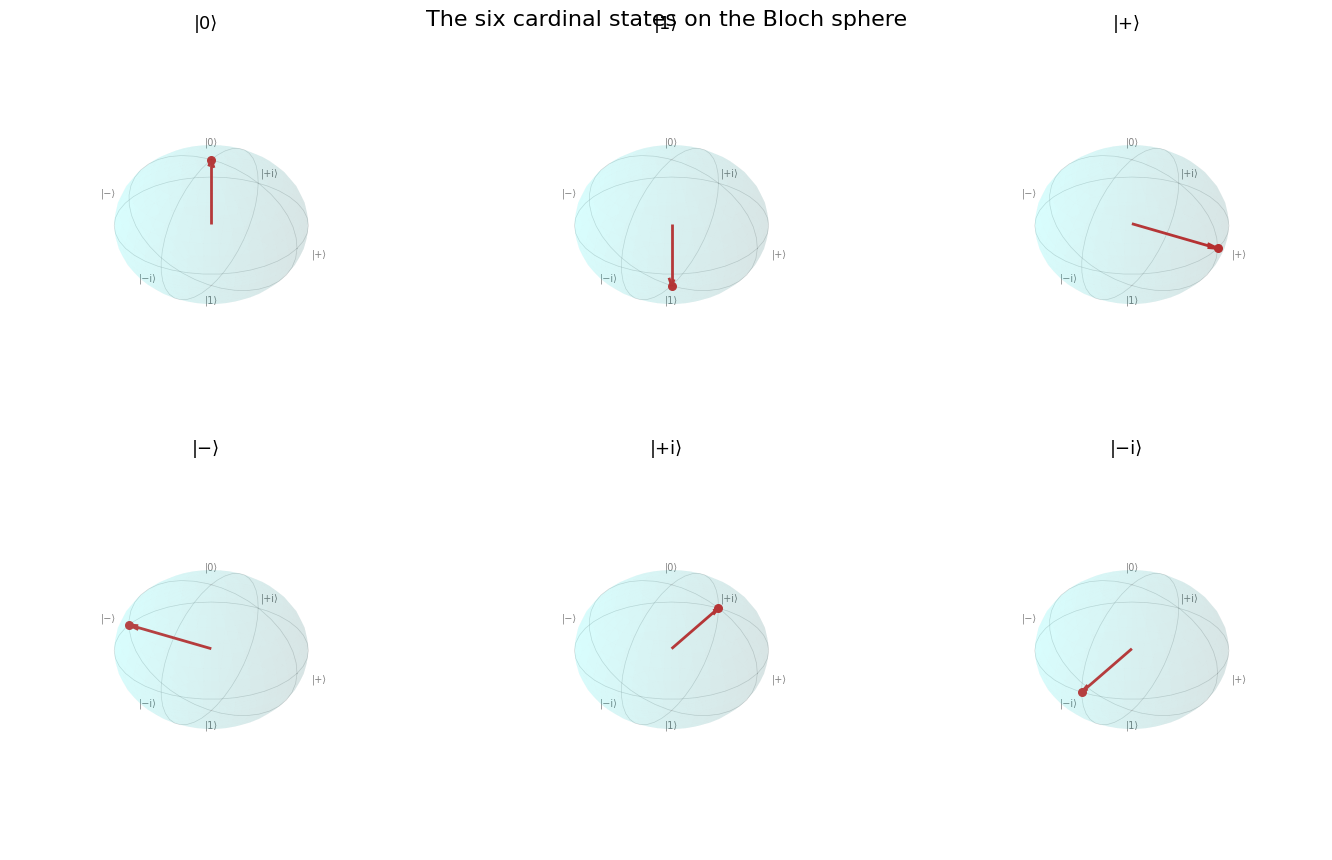

In [34]:
from mpl_toolkits.mplot3d import Axes3D

def bloch_vector(state_col):
    """Compute (x, y, z) Bloch vector from a 2x1 column state vector."""
    a, b = state_col.flatten()
    return (2*(a.conjugate()*b).real,
            2*(a.conjugate()*b).imag,
            float(abs(a)**2 - abs(b)**2))

def draw_bloch(ax, state_col, title=''):
    """Draw a Bloch sphere with a state arrow on a 3D matplotlib axis."""
    u = np.linspace(0, 2*np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, alpha=0.08, color='cyan', edgecolor='none')

    ax.plot(np.cos(u), np.sin(u), np.zeros_like(u), color='gray', alpha=0.3, lw=0.5)
    ax.plot(np.zeros_like(u), np.cos(u), np.sin(u), color='gray', alpha=0.3, lw=0.5)
    ax.plot(np.cos(u), np.zeros_like(u), np.sin(u), color='gray', alpha=0.3, lw=0.5)

    for endpoint, label in [([0,0,1],'|0⟩'), ([0,0,-1],'|1⟩'),
                             ([1,0,0],'|+⟩'), ([-1,0,0],'|−⟩'),
                             ([0,1,0],'|+i⟩'), ([0,-1,0],'|−i⟩')]:
        ax.text(endpoint[0]*1.25, endpoint[1]*1.25, endpoint[2]*1.25,
                label, fontsize=7, ha='center', va='center', color='gray')

    rx, ry, rz = bloch_vector(state_col)
    ax.quiver(0, 0, 0, rx, ry, rz, color='tab:red', arrow_length_ratio=0.12, linewidth=2)
    ax.scatter([rx], [ry], [rz], color='tab:red', s=30, zorder=5)

    ax.set_xlim([-1.3, 1.3])
    ax.set_ylim([-1.3, 1.3])
    ax.set_zlim([-1.3, 1.3])
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=13, pad=0)

named_states = {
    '|0⟩': ket0,
    '|1⟩': ket1,
    '|+⟩': (ket0 + ket1) / np.sqrt(2),
    '|−⟩': (ket0 - ket1) / np.sqrt(2),
    '|+i⟩': (ket0 + 1j*ket1) / np.sqrt(2),
    '|−i⟩': (ket0 - 1j*ket1) / np.sqrt(2),
}

fig = plt.figure(figsize=(14, 9))
for idx, (label, vec) in enumerate(named_states.items()):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    draw_bloch(ax, vec, title=label)

plt.suptitle('The six cardinal states on the Bloch sphere', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

### 5.7 Visualizing gate action on the Bloch sphere

Let's see how gates *move* states on the Bloch sphere. We start with $|0\rangle$ (north pole)
and apply various gates.

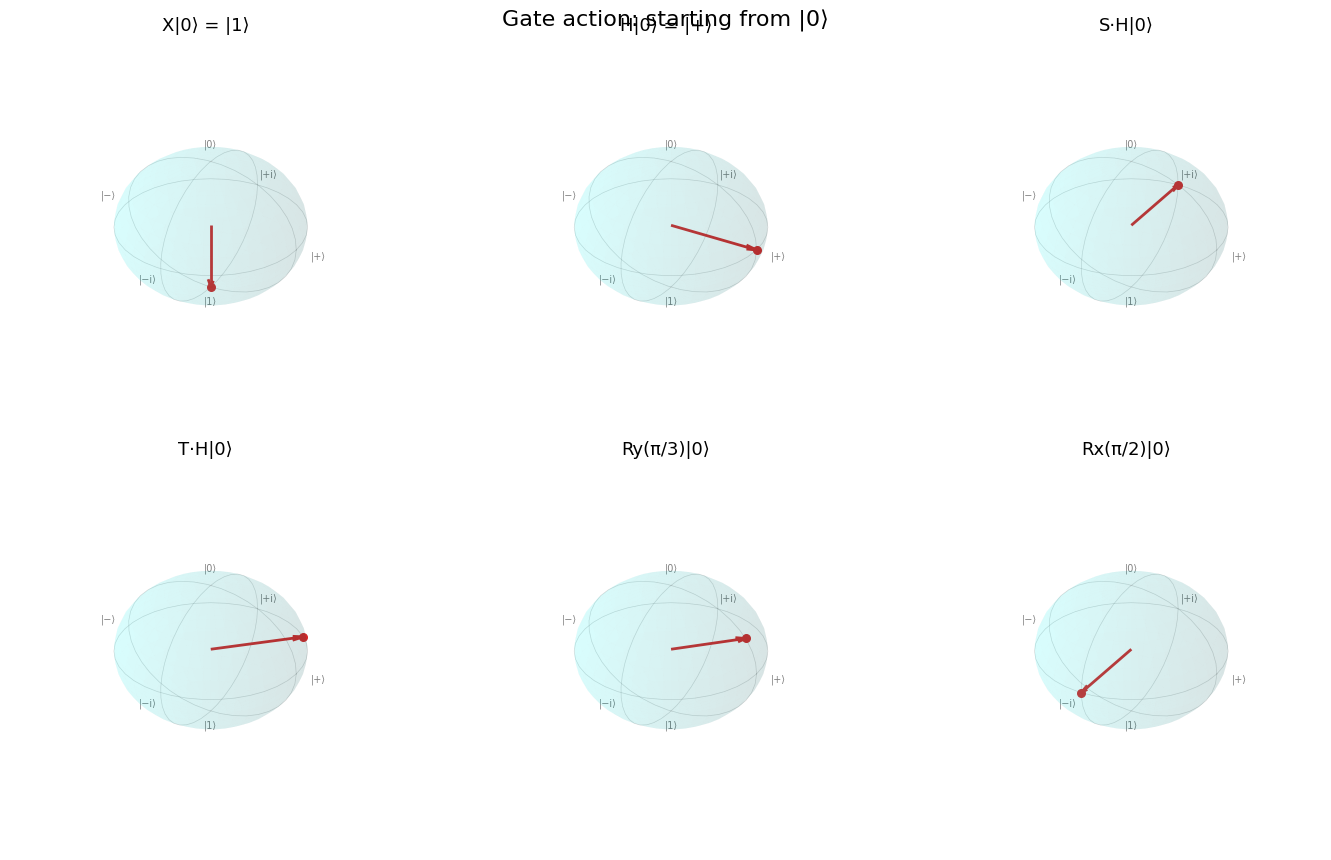

In [35]:
gates_demo = {
    'X|0⟩ = |1⟩': X @ ket0,
    'H|0⟩ = |+⟩': H_gate @ ket0,
    'S·H|0⟩': S @ H_gate @ ket0,
    'T·H|0⟩': T @ H_gate @ ket0,
    'Ry(π/3)|0⟩': Ry(np.pi/3) @ ket0,
    'Rx(π/2)|0⟩': Rx(np.pi/2) @ ket0,
}

fig = plt.figure(figsize=(14, 9))
for idx, (label, vec) in enumerate(gates_demo.items()):
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    draw_bloch(ax, vec, title=label)

plt.suptitle('Gate action: starting from |0⟩', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

### Checkpoint 4

**Task:**
1. Verify that $XZ = -ZX$ (the Pauli matrices **anticommute**).
2. Compute $HZH$ and identify which Pauli gate it equals.
3. Create the state $|{+i}\rangle = \frac{1}{\sqrt{2}}(|0\rangle + i|1\rangle)$ and verify it lies on the +Y axis of the Bloch sphere.

*Expected:* (1) True; (2) $HZH = X$; (3) the Bloch vector is $(0, 1, 0)$.

In [36]:
# Checkpoint 4
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
H_gate = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

# 1. Verify XZ = -ZX (anticommutation)
print("XZ =\n", X @ Z)
print("-ZX =\n", -(Z @ X))
print("XZ = -ZX?", np.allclose(X @ Z, -(Z @ X)))

# 2. Compute HZH and identify which Pauli gate it equals
HZH = H_gate @ Z @ H_gate
print(f"\nHZH =\n{HZH}")
print("HZH = X?", np.allclose(HZH, X))

# 3. |+i⟩ = (|0⟩ + i|1⟩)/√2, verify Bloch vector is (0, 1, 0)
psi_pi = (ket0 + 1j * ket1) / np.sqrt(2)
a, b = psi_pi.flatten()
bloch_x = 2 * (a.conjugate() * b).real
bloch_y = 2 * (a.conjugate() * b).imag
bloch_z = float(abs(a)**2 - abs(b)**2)
print(f"\n|+i⟩ Bloch vector: ({bloch_x:.4f}, {bloch_y:.4f}, {bloch_z:.4f})")
print("Is (0, 1, 0)?", np.allclose([bloch_x, bloch_y, bloch_z], [0, 1, 0]))

XZ =
 [[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]
-ZX =
 [[-0.-0.j -1.-0.j]
 [ 1.-0.j -0.-0.j]]
XZ = -ZX? True

HZH =
[[-0.+0.j  1.+0.j]
 [ 1.+0.j -0.+0.j]]
HZH = X? True

|+i⟩ Bloch vector: (0.0000, 1.0000, 0.0000)
Is (0, 1, 0)? True


---

# Section 6 — Multi-Qubit Systems and Entanglement

> **Goal:** Understand tensor products, multi-qubit states, and the concept of entanglement.

---

### 6.1 Tensor products

When we combine two qubits, the state space is the **tensor product** $\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$.

$$
|a\rangle \otimes |b\rangle = |a\rangle|b\rangle = |ab\rangle.
$$

For example:

$$
|00\rangle = \begin{bmatrix}1\\0\\0\\0\end{bmatrix}, \quad
|01\rangle = \begin{bmatrix}0\\1\\0\\0\end{bmatrix}, \quad
|10\rangle = \begin{bmatrix}0\\0\\1\\0\end{bmatrix}, \quad
|11\rangle = \begin{bmatrix}0\\0\\0\\1\end{bmatrix}.
$$

In NumPy, the tensor product is computed with `np.kron` (Kronecker product).

In [37]:
ket00 = np.kron(ket0, ket0)
ket01 = np.kron(ket0, ket1)
ket10 = np.kron(ket1, ket0)
ket11 = np.kron(ket1, ket1)

print("|00⟩ =", ket00.flatten())
print("|01⟩ =", ket01.flatten())
print("|10⟩ =", ket10.flatten())
print("|11⟩ =", ket11.flatten())

print("\nOrthogonality check:")
for label_a, a in [('00', ket00), ('01', ket01), ('10', ket10), ('11', ket11)]:
    for label_b, b in [('00', ket00), ('01', ket01), ('10', ket10), ('11', ket11)]:
        if label_a <= label_b:
            print(f"  ⟨{label_a}|{label_b}⟩ = {np.vdot(a, b).real:.0f}", end="  ")
    print()

|00⟩ = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|01⟩ = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
|10⟩ = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
|11⟩ = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Orthogonality check:
  ⟨00|00⟩ = 1    ⟨00|01⟩ = 0    ⟨00|10⟩ = 0    ⟨00|11⟩ = 0  
  ⟨01|01⟩ = 1    ⟨01|10⟩ = 0    ⟨01|11⟩ = 0  
  ⟨10|10⟩ = 1    ⟨10|11⟩ = 0  
  ⟨11|11⟩ = 1  


### 6.2 Product states vs. entangled states

A **product state** can be written as $|\psi\rangle = |a\rangle \otimes |b\rangle$ — each qubit has its own independent state.

An **entangled state** *cannot* be factored this way. The qubits are correlated in a way that has no classical analogue.

The simplest example is the **Bell state** (or EPR pair):

$$
|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

This state says: "both qubits are $|0\rangle$ **or** both are $|1\rangle$, with equal probability,
but the individual qubit states are undefined until measured."

> **Einstein** called this "spooky action at a distance."

The four **Bell states** form a complete basis for two-qubit entangled states:

$$
\begin{aligned}
|\Phi^+\rangle &= \frac{|00\rangle + |11\rangle}{\sqrt{2}}, &\quad
|\Phi^-\rangle &= \frac{|00\rangle - |11\rangle}{\sqrt{2}}, \\[6pt]
|\Psi^+\rangle &= \frac{|01\rangle + |10\rangle}{\sqrt{2}}, &\quad
|\Psi^-\rangle &= \frac{|01\rangle - |10\rangle}{\sqrt{2}}.
\end{aligned}
$$

In [38]:
phi_plus  = (ket00 + ket11) / np.sqrt(2)
phi_minus = (ket00 - ket11) / np.sqrt(2)
psi_plus  = (ket01 + ket10) / np.sqrt(2)
psi_minus = (ket01 - ket10) / np.sqrt(2)

print("Bell states:")
for label, state in [('|Φ⁺⟩', phi_plus), ('|Φ⁻⟩', phi_minus),
                     ('|Ψ⁺⟩', psi_plus), ('|Ψ⁻⟩', psi_minus)]:
    print(f"  {label} = {state.flatten()}")

print("\nOrthonormality of Bell basis:")
bell_states = [phi_plus, phi_minus, psi_plus, psi_minus]
bell_labels = ['Φ⁺', 'Φ⁻', 'Ψ⁺', 'Ψ⁻']
for i, (li, si) in enumerate(zip(bell_labels, bell_states)):
    for j, (lj, sj) in enumerate(zip(bell_labels, bell_states)):
        if i <= j:
            print(f"  ⟨{li}|{lj}⟩ = {np.vdot(si, sj).real:.0f}", end="  ")
    print()

Bell states:
  |Φ⁺⟩ = [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]
  |Φ⁻⟩ = [ 0.7071+0.j  0.    +0.j  0.    +0.j -0.7071+0.j]
  |Ψ⁺⟩ = [0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j]
  |Ψ⁻⟩ = [ 0.    +0.j  0.7071+0.j -0.7071+0.j  0.    +0.j]

Orthonormality of Bell basis:
  ⟨Φ⁺|Φ⁺⟩ = 1    ⟨Φ⁺|Φ⁻⟩ = 0    ⟨Φ⁺|Ψ⁺⟩ = 0    ⟨Φ⁺|Ψ⁻⟩ = 0  
  ⟨Φ⁻|Φ⁻⟩ = 1    ⟨Φ⁻|Ψ⁺⟩ = 0    ⟨Φ⁻|Ψ⁻⟩ = 0  
  ⟨Ψ⁺|Ψ⁺⟩ = 1    ⟨Ψ⁺|Ψ⁻⟩ = 0  
  ⟨Ψ⁻|Ψ⁻⟩ = 1  


### 6.3 The CNOT gate

The **Controlled-NOT (CNOT or CX)** gate is the standard two-qubit entangling gate:

$$
\text{CNOT} = \begin{bmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{bmatrix}.
$$

It flips the **target** qubit if and only if the **control** qubit is $\lvert 1\rangle$:

| Input | Output | Explanation |
|-------|--------|-------------|
| $\lvert 00\rangle$ | $\lvert 00\rangle$ | Control = 0 → target unchanged |
| $\lvert 01\rangle$ | $\lvert 01\rangle$ | Control = 0 → target unchanged |
| $\lvert 10\rangle$ | $\lvert 11\rangle$ | Control = 1 → target flipped |
| $\lvert 11\rangle$ | $\lvert 10\rangle$ | Control = 1 → target flipped |

> **Creating entanglement:** $\text{CNOT}\cdot(H \otimes I)\lvert 00\rangle = \lvert\Phi^+\rangle$.

In [39]:
CNOT = np.array([[1,0,0,0],
                  [0,1,0,0],
                  [0,0,0,1],
                  [0,0,1,0]], dtype=complex)

print("CNOT truth table:")
for label, basis in [('|00⟩', ket00), ('|01⟩', ket01), ('|10⟩', ket10), ('|11⟩', ket11)]:
    result = CNOT @ basis
    print(f"  CNOT{label} = {result.flatten()}")

HI = np.kron(H_gate, I2)
bell = CNOT @ HI @ ket00
print(f"\nCNOT·(H⊗I)|00⟩ = {bell.flatten()}  = |Φ⁺⟩? {np.allclose(bell, phi_plus)}")

CNOT truth table:
  CNOT|00⟩ = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
  CNOT|01⟩ = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
  CNOT|10⟩ = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
  CNOT|11⟩ = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]

CNOT·(H⊗I)|00⟩ = [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]  = |Φ⁺⟩? True


### 6.4 Measuring entangled states

When we measure the Bell state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$:

- $\Pr(00) = |1/\sqrt{2}|^2 = 1/2$
- $\Pr(11) = |1/\sqrt{2}|^2 = 1/2$
- $\Pr(01) = \Pr(10) = 0$

The outcomes are **perfectly correlated**: if one qubit is measured as 0, the other is *guaranteed* to be 0 too, regardless of the distance between them.

In [40]:
print("Measurement probabilities for |Φ⁺⟩:")
for label, basis in [('00', ket00), ('01', ket01), ('10', ket10), ('11', ket11)]:
    prob = abs(np.vdot(basis, phi_plus))**2
    print(f"  Pr({label}) = {prob:.4f}")

Measurement probabilities for |Φ⁺⟩:
  Pr(00) = 0.5000
  Pr(01) = 0.0000
  Pr(10) = 0.0000
  Pr(11) = 0.5000


### Checkpoint 5

**Task:**
1. Verify that CNOT is unitary.
2. Create the Bell state $|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$ using gates (hint: apply $X$ to qubit 1 before the Bell circuit).
3. Compute the measurement probabilities of $|\Psi^+\rangle$.

*Expected:* $\Pr(01) = \Pr(10) = 1/2$, all others zero.

In [41]:
# Checkpoint 5
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
H_gate = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)

CNOT = np.array([[1,0,0,0],
                  [0,1,0,0],
                  [0,0,0,1],
                  [0,0,1,0]], dtype=complex)

# 1. Verify CNOT is unitary
print("CNOT is unitary?", np.allclose(CNOT.conj().T @ CNOT, np.eye(4)))

# 2. Create |Ψ⁺⟩ using gates: apply X to qubit 1 first, then H⊗I, then CNOT
ket00 = np.kron(ket0, ket0)
ket01 = np.kron(ket0, ket1)
ket10 = np.kron(ket1, ket0)
ket11 = np.kron(ket1, ket1)

# Start with |00⟩, apply I⊗X to get |01⟩, then H⊗I, then CNOT
IX = np.kron(I2, X)
HI = np.kron(H_gate, I2)
psi_plus = CNOT @ HI @ IX @ ket00
print(f"\n|Ψ⁺⟩ = {psi_plus.flatten()}")

# 3. Measurement probabilities
print("\nMeasurement probabilities of |Ψ⁺⟩:")
for label, basis in [('00', ket00), ('01', ket01), ('10', ket10), ('11', ket11)]:
    prob = abs(np.vdot(basis, psi_plus))**2
    print(f"  Pr({label}) = {prob:.4f}")

CNOT is unitary? True

|Ψ⁺⟩ = [0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j]

Measurement probabilities of |Ψ⁺⟩:
  Pr(00) = 0.0000
  Pr(01) = 0.5000
  Pr(10) = 0.5000
  Pr(11) = 0.0000


---

# Section 7 — Your First Quantum Circuits in Qiskit

> **Goal:** Build, simulate, and visualize quantum circuits using Qiskit.

Qiskit is IBM's open-source framework for quantum computing. It lets you:
1. **Build** circuits from gates
2. **Simulate** them on a classical computer
3. **Run** them on real quantum hardware (with an IBM Quantum account)

---

### 7.1 Building a circuit

A `QuantumCircuit(n_qubits, n_classical_bits)` is a sequence of gates and measurements.

In [42]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

print("Text diagram:")
print(qc.draw('text'))

Text diagram:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


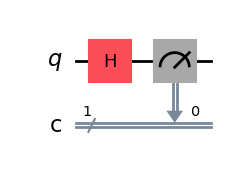

In [43]:
qc.draw('mpl')

### 7.2 Simulating measurement

The simulator runs the circuit many times (*shots*) and collects statistics.
With more shots, the frequencies converge to the theoretical probabilities.

Counts: {'0': 2005, '1': 2091}


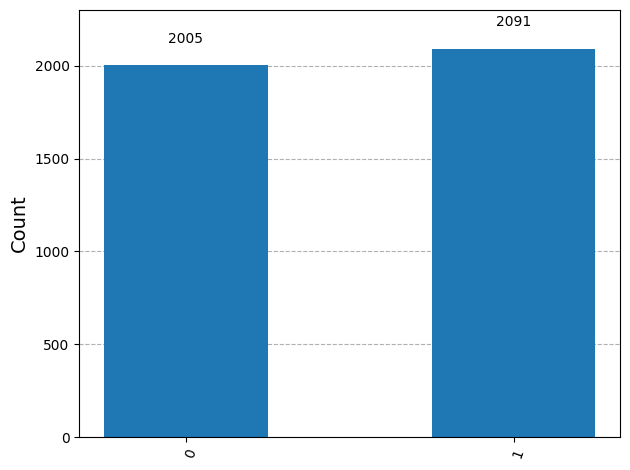

In [44]:
result = SIM_BACKEND.run(qc, shots=4096).result()
counts = result.get_counts()
print("Counts:", counts)

plot_histogram(counts)

### 7.3 Statevector simulation (no measurement)

We can also extract the **exact statevector** before measurement, with no sampling noise.

Statevector after H: Statevector([0.7071+0.j, 0.7071+0.j],
            dims=(2,))
Probabilities: {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


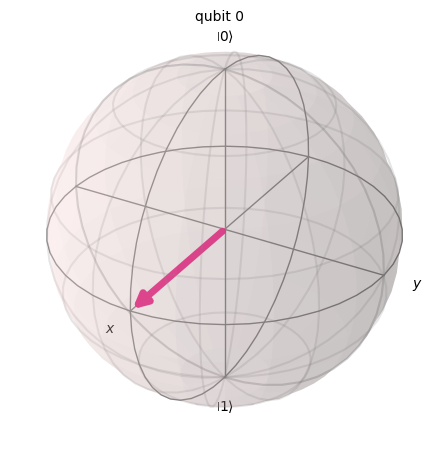

In [45]:
qc_sv = QuantumCircuit(1)
qc_sv.h(0)

sv = Statevector.from_instruction(qc_sv)
print("Statevector after H:", sv)
print("Probabilities:", sv.probabilities_dict())

plot_bloch_multivector(sv)

### 7.4 Multi-gate circuits

Let's explore several single-qubit circuits and compare theory with simulation.

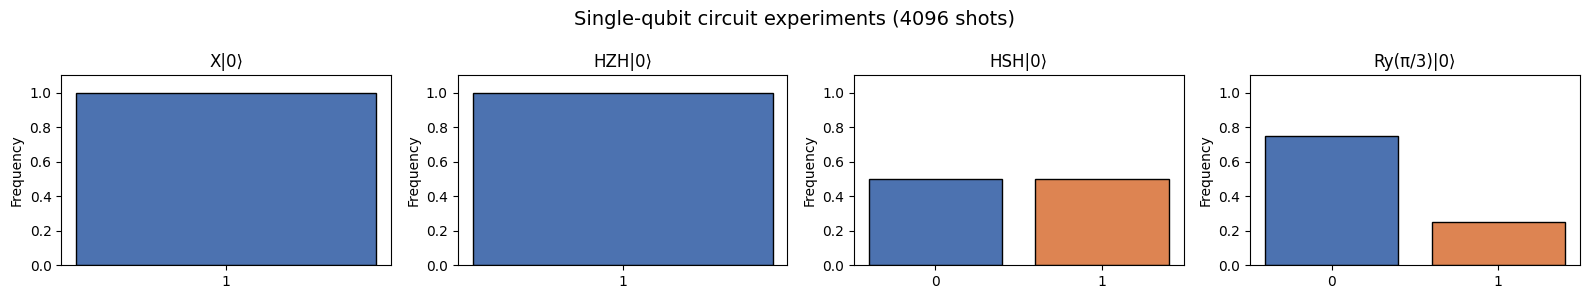

In [46]:
circuits = {}

qc1 = QuantumCircuit(1, 1)
qc1.x(0)
qc1.measure(0, 0)
circuits['X|0⟩'] = qc1

qc2 = QuantumCircuit(1, 1)
qc2.h(0)
qc2.z(0)
qc2.h(0)
qc2.measure(0, 0)
circuits['HZH|0⟩'] = qc2

qc3 = QuantumCircuit(1, 1)
qc3.h(0)
qc3.s(0)
qc3.h(0)
qc3.measure(0, 0)
circuits['HSH|0⟩'] = qc3

qc4 = QuantumCircuit(1, 1)
qc4.ry(np.pi/3, 0)
qc4.measure(0, 0)
circuits['Ry(π/3)|0⟩'] = qc4

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (label, circ) in zip(axes, circuits.items()):
    result = SIM_BACKEND.run(circ, shots=4096).result()
    counts = result.get_counts()
    total = sum(counts.values())
    probs = {k: v/total for k, v in sorted(counts.items())}
    ax.bar(probs.keys(), probs.values(), color=['#4C72B0', '#DD8452'][:len(probs)], edgecolor='black')
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.set_ylabel('Frequency')

plt.suptitle('Single-qubit circuit experiments (4096 shots)', fontsize=14)
plt.tight_layout()
plt.show()

### 7.5 Bell state circuit

The canonical way to create the Bell state $|\Phi^+\rangle$:
1. Apply $H$ to qubit 0
2. Apply CNOT with control=0, target=1

In [47]:
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
qc_bell.measure([0, 1], [0, 1])

print(qc_bell.draw('text'))

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


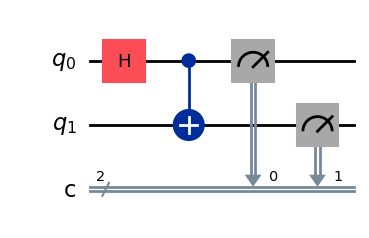

In [48]:
qc_bell.draw('mpl')

Bell state counts: {'00': 2059, '11': 2037}


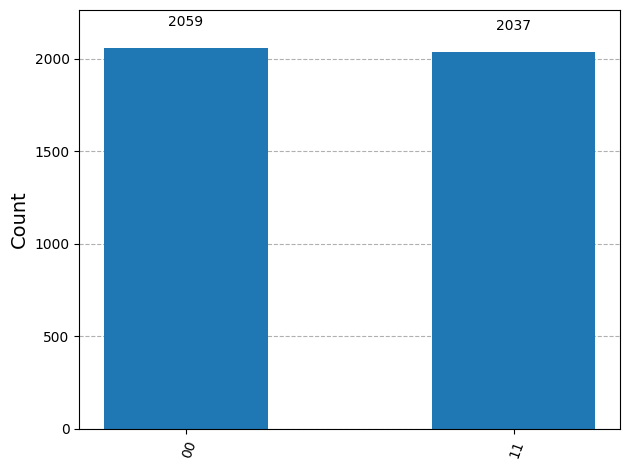

In [49]:
result_bell = SIM_BACKEND.run(qc_bell, shots=4096).result()
counts_bell = result_bell.get_counts()
print("Bell state counts:", counts_bell)

plot_histogram(counts_bell)

### 7.6 Statevector of the Bell state

Bell statevector: Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2))
Probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


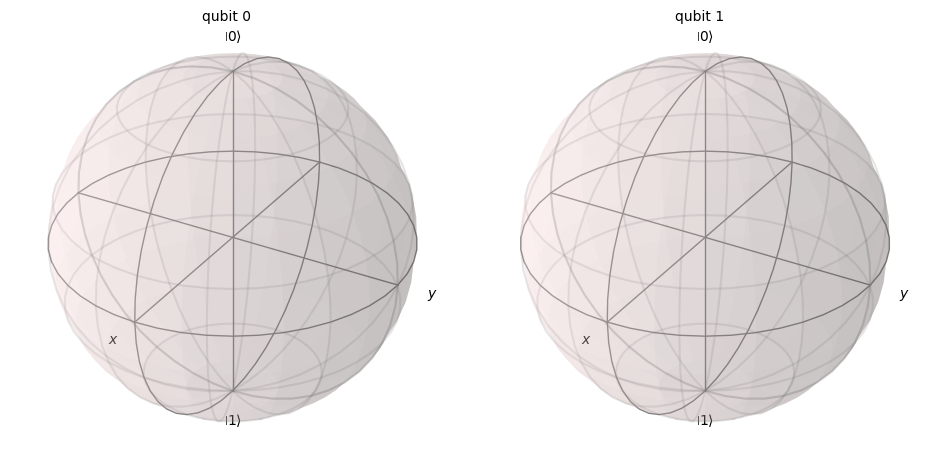

In [50]:
qc_bell_sv = QuantumCircuit(2)
qc_bell_sv.h(0)
qc_bell_sv.cx(0, 1)

sv_bell = Statevector.from_instruction(qc_bell_sv)
print("Bell statevector:", sv_bell)
print("Probabilities:", sv_bell.probabilities_dict())

plot_bloch_multivector(sv_bell)

### 7.7 Comparing shot counts

More shots → frequencies closer to true probabilities. Let's see this empirically.

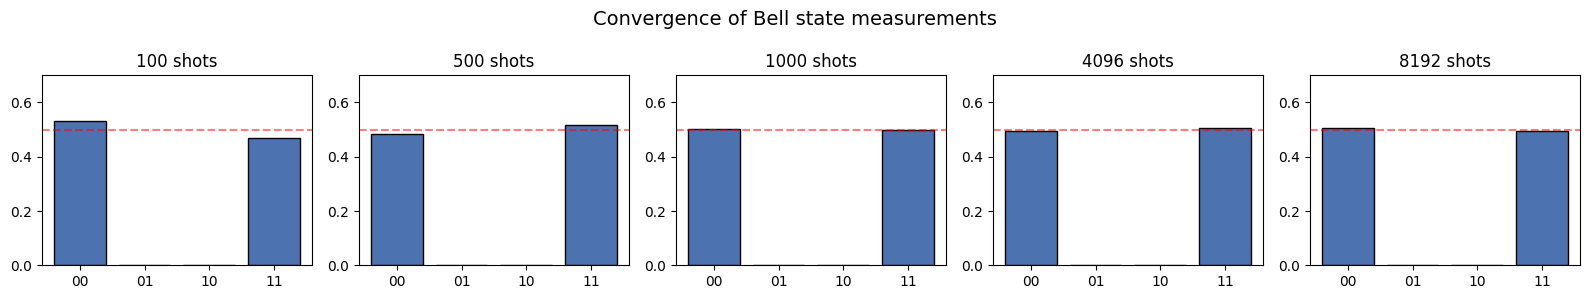

In [51]:
shot_counts = [100, 500, 1000, 4096, 8192]

fig, axes = plt.subplots(1, len(shot_counts), figsize=(16, 3))
for ax, shots in zip(axes, shot_counts):
    result = SIM_BACKEND.run(qc_bell, shots=shots).result()
    counts = result.get_counts()
    total = sum(counts.values())
    probs = {k: counts.get(k, 0)/total for k in ['00', '01', '10', '11']}
    colors = ['#4C72B0' if k in ['00', '11'] else '#CCCCCC' for k in probs.keys()]
    ax.bar(probs.keys(), probs.values(), color=colors, edgecolor='black')
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 0.7)
    ax.set_title(f'{shots} shots')

plt.suptitle('Convergence of Bell state measurements', fontsize=14)
plt.tight_layout()
plt.show()

---

# Exercises

These exercises reinforce the concepts from the lab. Try them on your own before checking the solutions!

---

### Exercise 1: Custom state preparation

Create a circuit that prepares the state $|\psi\rangle = \cos(\pi/8)|0\rangle + \sin(\pi/8)|1\rangle$.

*Hint:* Use `qc.ry(theta, 0)` where $\theta = \pi/4$ (since $R_y(\theta)|0\rangle = \cos(\theta/2)|0\rangle + \sin(\theta/2)|1\rangle$).

Verify by:
1. Computing the exact statevector
2. Comparing simulated measurement frequencies with $|\alpha|^2$ and $|\beta|^2$

Statevector: Statevector([0.9239+0.j, 0.3827+0.j],
            dims=(2,))
Probabilities: {np.str_('0'): np.float64(0.8535533905932737), np.str_('1'): np.float64(0.14644660940672624)}
Expected: Pr(0) = cos²(π/8) = 0.8536, Pr(1) = sin²(π/8) = 0.1464

Simulated counts: {'0': 3521, '1': 575}


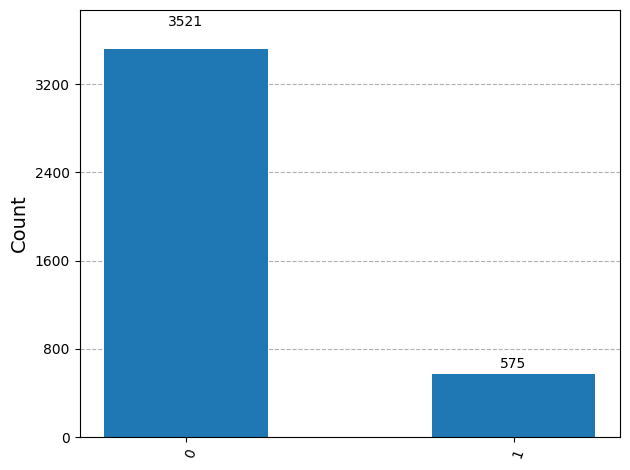

In [52]:
# Exercise 1: Custom state preparation
# |ψ⟩ = cos(π/8)|0⟩ + sin(π/8)|1⟩  →  Ry(π/4)|0⟩

qc_ex1 = QuantumCircuit(1, 1)
qc_ex1.ry(np.pi/4, 0)
qc_ex1.measure(0, 0)

# 1. Exact statevector
qc_ex1_sv = QuantumCircuit(1)
qc_ex1_sv.ry(np.pi/4, 0)
sv_ex1 = Statevector.from_instruction(qc_ex1_sv)
print("Statevector:", sv_ex1)
print("Probabilities:", sv_ex1.probabilities_dict())
print(f"Expected: Pr(0) = cos²(π/8) = {np.cos(np.pi/8)**2:.4f}, Pr(1) = sin²(π/8) = {np.sin(np.pi/8)**2:.4f}")

# 2. Simulated measurement
result_ex1 = SIM_BACKEND.run(qc_ex1, shots=4096).result()
counts_ex1 = result_ex1.get_counts()
print("\nSimulated counts:", counts_ex1)
plot_histogram(counts_ex1)

### Exercise 2: GHZ state (3-qubit entanglement)

> **Deep dive (optional)** — attempt this exercise at home if time is short.

A **GHZ state** generalizes the Bell state to 3 qubits:

$$
|\text{GHZ}\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}.
$$

Build it with: H on qubit 0, then CNOT(0→1), then CNOT(0→2).

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 

GHZ statevector: Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.    +0.j, 0.    +0.j,
             0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2, 2))
Probabilities: {np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}

Counts: {'000': 2126, '111': 1970}


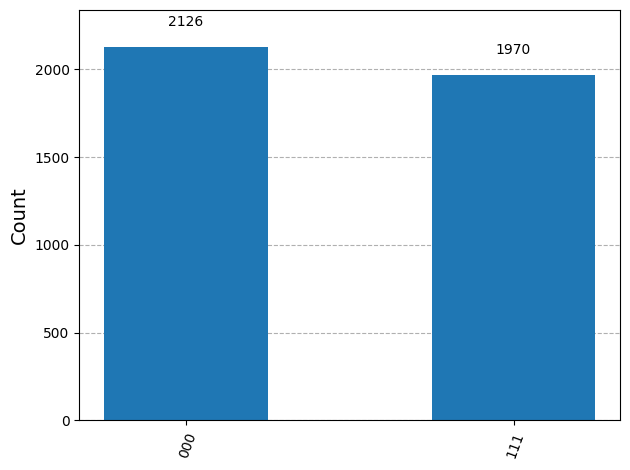

In [53]:
# Exercise 2: GHZ state  |GHZ⟩ = (|000⟩ + |111⟩)/√2
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)
qc_ghz.measure([0, 1, 2], [0, 1, 2])

print(qc_ghz.draw('text'))

# Statevector
qc_ghz_sv = QuantumCircuit(3)
qc_ghz_sv.h(0)
qc_ghz_sv.cx(0, 1)
qc_ghz_sv.cx(0, 2)
sv_ghz = Statevector.from_instruction(qc_ghz_sv)
print("\nGHZ statevector:", sv_ghz)
print("Probabilities:", sv_ghz.probabilities_dict())

# Simulation
result_ghz = SIM_BACKEND.run(qc_ghz, shots=4096).result()
counts_ghz = result_ghz.get_counts()
print("\nCounts:", counts_ghz)
plot_histogram(counts_ghz)

### Exercise 3: Quantum interference

Build a circuit that demonstrates **destructive interference**:

1. Apply $H$ to $|0\rangle$ → get $|+\rangle$
2. Apply $H$ again → back to $|0\rangle$!

This shows that $H^2 = I$. Then try inserting a $Z$ gate between the two $H$ gates and observe the change.

H²|0⟩ counts: {'0': 4096}  → always |0⟩ (destructive interference cancels |1⟩)
HZH|0⟩ counts: {'1': 4096}  → always |1⟩ (Z flips relative phase, changing interference)


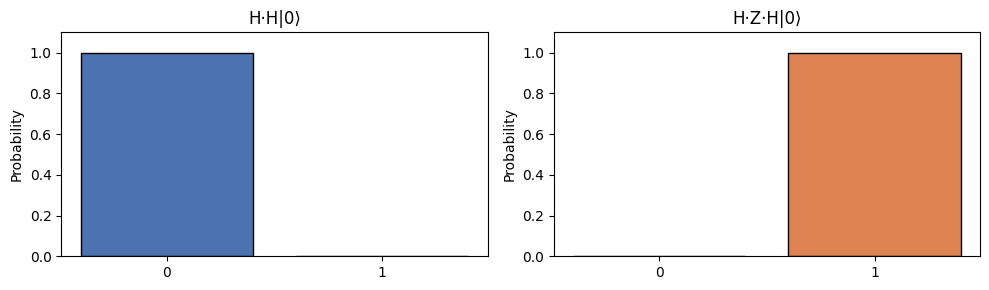

In [54]:
# Exercise 3: Quantum interference

# Part 1: H² = I  →  H|0⟩ = |+⟩, then H|+⟩ = |0⟩
qc_hh = QuantumCircuit(1, 1)
qc_hh.h(0)
qc_hh.h(0)
qc_hh.measure(0, 0)

result_hh = SIM_BACKEND.run(qc_hh, shots=4096).result()
counts_hh = result_hh.get_counts()
print("H²|0⟩ counts:", counts_hh, " → always |0⟩ (destructive interference cancels |1⟩)")

# Part 2: Insert Z between two H gates  →  HZH|0⟩ = X|0⟩ = |1⟩
qc_hzh = QuantumCircuit(1, 1)
qc_hzh.h(0)
qc_hzh.z(0)
qc_hzh.h(0)
qc_hzh.measure(0, 0)

result_hzh = SIM_BACKEND.run(qc_hzh, shots=4096).result()
counts_hzh = result_hzh.get_counts()
print("HZH|0⟩ counts:", counts_hzh, " → always |1⟩ (Z flips relative phase, changing interference)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (title, counts) in zip(axes, [("H·H|0⟩", counts_hh), ("H·Z·H|0⟩", counts_hzh)]):
    total = sum(counts.values())
    probs = {k: counts.get(k, 0)/total for k in ['0', '1']}
    ax.bar(probs.keys(), probs.values(), color=['#4C72B0', '#DD8452'], edgecolor='black')
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.set_ylabel('Probability')
plt.tight_layout()
plt.show()

### Exercise 4: All four Bell states

Create circuits for all four Bell states and verify their measurement statistics.

| Bell state | Circuit |
|-----------|--------|
| $\lvert\Phi^+\rangle$ | $H_0$, CNOT(0,1) on $\lvert 00\rangle$ |
| $\lvert\Phi^-\rangle$ | $H_0$, CNOT(0,1) on $\lvert 10\rangle$ |
| $\lvert\Psi^+\rangle$ | $H_0$, CNOT(0,1) on $\lvert 01\rangle$ |
| $\lvert\Psi^-\rangle$ | $H_0$, CNOT(0,1) on $\lvert 11\rangle$ |

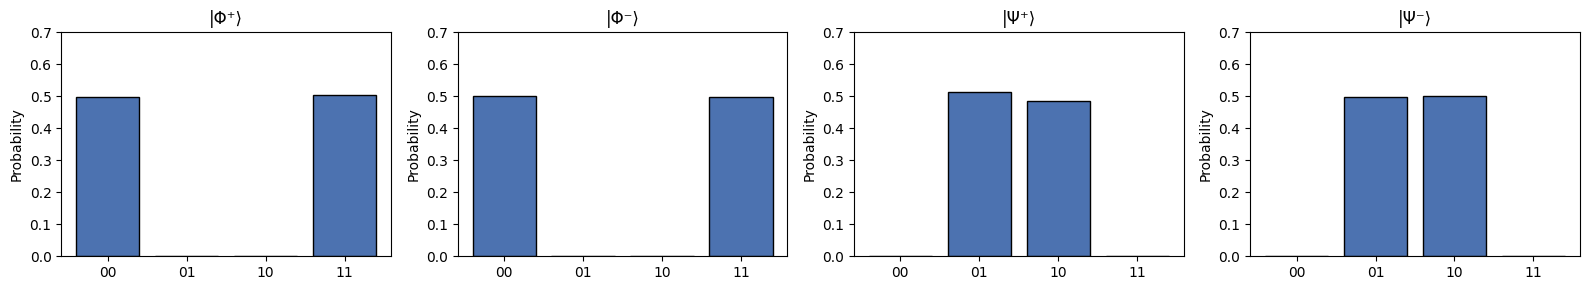

In [55]:
# Exercise 4: All four Bell states

bell_circuits = {}

# |Φ⁺⟩: H on q0, CNOT, starting from |00⟩
qc1 = QuantumCircuit(2, 2)
qc1.h(0)
qc1.cx(0, 1)
qc1.measure([0, 1], [0, 1])
bell_circuits['|Φ⁺⟩'] = qc1

# |Φ⁻⟩: X on q0, then H on q0, CNOT (start from |10⟩)
qc2 = QuantumCircuit(2, 2)
qc2.x(0)
qc2.h(0)
qc2.cx(0, 1)
qc2.measure([0, 1], [0, 1])
bell_circuits['|Φ⁻⟩'] = qc2

# |Ψ⁺⟩: X on q1, then H on q0, CNOT (start from |01⟩)
qc3 = QuantumCircuit(2, 2)
qc3.x(1)
qc3.h(0)
qc3.cx(0, 1)
qc3.measure([0, 1], [0, 1])
bell_circuits['|Ψ⁺⟩'] = qc3

# |Ψ⁻⟩: X on q0 and q1, then H on q0, CNOT (start from |11⟩)
qc4 = QuantumCircuit(2, 2)
qc4.x(0)
qc4.x(1)
qc4.h(0)
qc4.cx(0, 1)
qc4.measure([0, 1], [0, 1])
bell_circuits['|Ψ⁻⟩'] = qc4

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (label, circ) in zip(axes, bell_circuits.items()):
    result = SIM_BACKEND.run(circ, shots=4096).result()
    counts = result.get_counts()
    total = sum(counts.values())
    probs = {k: counts.get(k, 0)/total for k in ['00', '01', '10', '11']}
    colors = ['#4C72B0' if v > 0.1 else '#CCCCCC' for v in probs.values()]
    ax.bar(probs.keys(), probs.values(), color=colors, edgecolor='black')
    ax.set_ylim(0, 0.7)
    ax.set_title(label)
    ax.set_ylabel('Probability')
plt.tight_layout()
plt.show()

---

# Wrap-up

## What we learned

| Concept | Mathematical notation | NumPy / Qiskit |
|---------|----------------------|----------------|
| Qubit state | $\lvert\psi\rangle = \alpha\lvert 0\rangle + \beta\lvert 1\rangle$ | `np.array([[alpha], [beta]])` |
| Inner product | $\langle\phi\lvert\psi\rangle$ | `np.vdot(phi, psi)` |
| Outer product | $\lvert\psi\rangle\langle\phi\rvert$ | `psi @ phi.conj().T` |
| Born rule | $\Pr(k) = \lvert\langle k\lvert\psi\rangle\rvert^2$ | `abs(np.vdot(ket_k, psi))**2` |
| Gate (unitary) | $U^\dagger U = I$ | matrix `@` or `qc.h()`, `qc.x()`, etc. |
| Tensor product | $\lvert a\rangle \otimes \lvert b\rangle$ | `np.kron(a, b)` |
| Entanglement | $\lvert\Phi^+\rangle = \frac{\lvert 00\rangle + \lvert 11\rangle}{\sqrt{2}}$ | `qc.h(0); qc.cx(0,1)` |

## Key takeaways

1. **Quantum states are vectors** in a complex Hilbert space.
2. **Measurement probabilities** come from the Born rule: $\Pr = \lvert\text{amplitude}\rvert^2$.
3. **Global phase** is unobservable; **relative phase** causes interference.
4. **Gates are unitary matrices** — they rotate the Bloch vector.
5. **Entanglement** creates correlations with no classical analogue.
6. **Qiskit** lets you build circuits, simulate them, and (later) run them on real quantum hardware.

## Reflection questions

- How does measurement collapse relate to the probability amplitudes $\lvert\alpha\rvert^2$, $\lvert\beta\rvert^2$?
- What changes if we measure in a different basis (e.g., apply $H$ before measuring)?
- Which parts felt most like linear algebra, and which parts felt genuinely new?
- Can you think of a physical system that behaves like a qubit?

## Next steps

- **Lecture 1** will formalize quantum mechanics axioms (state spaces, evolution, measurement).
- Try the [IBM Quantum Learning](https://learning.quantum.ibm.com/) platform for interactive exercises.
- Explore the [Qiskit Textbook](https://github.com/Qiskit/textbook) for deeper dives.

---

*Congratulations — you've taken your first steps into quantum computing!*